In [206]:
import paramak
import numpy as np

# === COLOR MAP by COMPONENT NAME KEYWORDS ===
color_map = {
    "plasma": [0.94, 0.012, 1],
    "first_wall": [0.8, 0.2, 0.2],
    "blanket": [0.3, 0.7, 0.3],
    "back_wall": [0.7, 0.7, 0.3],
    "He_manifolds": [0.85, 0.85, 0.1],
    "structural_ring": [0.2, 0.4, 0.7],
    "vv": [0.4, 0.4, 0.4],
    "shield": [0.6, 0.6, 0.95],
    "inner_coil_case": [0.5, 0.5, 0.8],
    "winding_pack": [0.1, 0.22, 0.33],
    "outer_coil_case": [0.2, 0.45, 0.67],
    "thermal_shield": [0.1, 0.26, 0.82],
    "central_solenoid": [0.85, 0.85, 0.1],
}

# === FUNCTION TO GET COLOR BASED ON NAME ===
def get_color(name):
    for key in color_map:
        if key in name:
            return color_map[key]
    return [0.9, 0.9, 0.9]  # default light gray

# === GEOMETRY PARAMETERS ===
inboard_angle_offset = 10
outboard_angle_offset = 5
plasma_offset = 10
first_wall_thickness = 4
inboard_blanket_thickness = 44
outboard_blanket_thickness = 96
back_wall_thickness = 2
He_manifolds_thickness = 6
structural_ring_thickness = 20
inboard_structural_ring_offset = 1
outboard_structural_ring_offset = 150
vv_thickness = 10
vv_offset = 2
inboard_shield_thickness = 23
outboard_shield_thickness = 17
rotation_angle = 180
num_points = 200

# === PLASMA ===
plasma = paramak.Plasma(
    major_radius=480,
    minor_radius=120,
    triangularity=0.625,
    elongation=2.2,
    rotation_angle=rotation_angle,
    name='plasma',
    color=get_color('plasma')
)

# === INBOARD COMPONENTS ===
offset = plasma_offset
inboard_angles = (90 + inboard_angle_offset, 270 - inboard_angle_offset)

inboard_first_wall = paramak.BlanketFP(
    first_wall_thickness, *inboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='inboard_first_wall',
    num_points=num_points, color=get_color('inboard_first_wall')
)
offset += first_wall_thickness

inboard_blanket = paramak.BlanketFP(
    inboard_blanket_thickness, *inboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='inboard_blanket',
    num_points=num_points, color=get_color('inboard_blanket')
)
offset += inboard_blanket_thickness

back_wall = paramak.BlanketFP(
    back_wall_thickness, *inboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='back_wall',
    num_points=num_points, color=get_color('back_wall')
)
offset += back_wall_thickness

inboard_He_manifolds = paramak.BlanketFP(
    He_manifolds_thickness, *inboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='inboard_He_manifolds',
    num_points=num_points, color=get_color('inboard_He_manifolds')
)
offset += He_manifolds_thickness

inboard_structural_ring = paramak.BlanketFP(
    structural_ring_thickness, *inboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='inboard_structural_ring',
    num_points=num_points, color=get_color('inboard_structural_ring')
)
offset += structural_ring_thickness + inboard_structural_ring_offset

inboard_vv = paramak.BlanketFP(
    vv_thickness, *inboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='inboard_vv',
    num_points=num_points, color=get_color('inboard_vv')
)
offset += vv_thickness + vv_offset

inboard_shield = paramak.BlanketFP(
    inboard_shield_thickness, *inboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='inboard_shield',
    num_points=num_points, color=get_color('inboard_shield')
)

# === OUTBOARD COMPONENTS ===
offset = plasma_offset
outboard_angles = (-90 + outboard_angle_offset, 90 - outboard_angle_offset)

outboard_first_wall = paramak.BlanketFP(
    first_wall_thickness, *outboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='outboard_first_wall',
    num_points=num_points, color=get_color('outboard_first_wall')
)
offset += first_wall_thickness

outboard_blanket = paramak.BlanketFP(
    outboard_blanket_thickness, *outboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='outboard_blanket',
    num_points=num_points, color=get_color('outboard_blanket')
)
offset += outboard_blanket_thickness

outboard_He_manifolds = paramak.BlanketFP(
    He_manifolds_thickness, *outboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='outboard_He_manifolds',
    num_points=num_points, color=get_color('outboard_He_manifolds')
)
offset += He_manifolds_thickness

outboard_structural_ring = paramak.BlanketFP(
    structural_ring_thickness, *outboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='outboard_structural_ring',
    num_points=num_points, color=get_color('outboard_structural_ring')
)
offset += structural_ring_thickness + outboard_structural_ring_offset

outboard_vv = paramak.BlanketFP(
    vv_thickness, *outboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='outboard_vv',
    num_points=num_points, color=get_color('outboard_vv')
)
offset += vv_thickness + vv_offset

outboard_shield = paramak.BlanketFP(
    outboard_shield_thickness, *outboard_angles,
    plasma=plasma, offset_from_plasma=offset,
    rotation_angle=rotation_angle, name='outboard_shield',
    num_points=num_points, color=get_color('outboard_shield')
)

# === CENTER COLUMN COMPONENTS ===
central_solenoid = paramak.CenterColumnShieldCylinder(
    height=1000,
    inner_radius=0,
    outer_radius=104.7,
    name='central_solenoid',
    color=get_color('central_solenoid')
)

coil_case_inner = paramak.CenterColumnShieldCylinder(
    height=1000,
    inner_radius=104.7,
    outer_radius=151.7,
    name='inner_coil_case',
    color=get_color('inner_coil_case')
)

winding_pack = paramak.CenterColumnShieldCylinder(
    height=1000,
    inner_radius=151.7,
    outer_radius=214.7,
    name='winding_pack',
    color=get_color('winding_pack')
)

coil_case_outer = paramak.CenterColumnShieldCylinder(
    height=1000,
    inner_radius=215.0,
    outer_radius=222.0,
    name='outer_coil_case',
    color=get_color('outer_coil_case')
)

thermal_shield = paramak.CenterColumnShieldCylinder(
    height=1000,
    inner_radius=222.0,
    outer_radius=224.0,
    name='thermal_shield',
    color=get_color('thermal_shield')
)

# === REACTOR ASSEMBLY ===
fnsf_reactor = paramak.Reactor(
    shapes_and_components=[
        plasma,
        inboard_first_wall, inboard_blanket, back_wall,
        inboard_He_manifolds, inboard_structural_ring, inboard_vv, inboard_shield,
        outboard_first_wall, outboard_blanket, outboard_He_manifolds,
        outboard_structural_ring, outboard_vv, outboard_shield,
        central_solenoid, coil_case_inner, coil_case_outer, winding_pack, thermal_shield,
    ]
)

# === DISPLAY MODEL ===
#fnsf_reactor.export_html_3d('my_reactor_3d.html')

ModuleNotFoundError: No module named 'paramak'

In [ ]:
import json
from pathlib import Path


if __name__ == '__main__':
    #fnsf_reactor.export_html_3d('fnsf_reactor.html')
    #fnsf_reactor.export_html('fnsf_reactor_2d.html')
    fnsf_reactor.export_stp(filename='ball_reactor.stp')
    fnsf_reactor.export_svg(filename='ball_reactor.svg', projectionDir=(0.8,-0.8,-0.2))
    fnsf_reactor.export_stl(filename='ball_reactor.stl')
    

    # Save the volume of each part to a JSON file for accessing later in OpenMC, useful for doing depletion calculations
    volumes = {}
    for shape in fnsf_reactor.shapes_and_components:
        volumes[shape.name] = shape.volume()

    with open("fnsf_reactor_volumes.json", "w") as outfile:
        json.dump(volumes, outfile, indent=4)

    # # Export DAGMC-compatible geometry
    fnsf_reactor.export_dagmc_h5m(
         filename='fnsf_reactor.h5m',
         min_mesh_size=5,
         max_mesh_size=20
     )


/home/rifat/miniconda3/envs/env_cad/lib/python3.9/site-packages/cadquery/utils.py:39: FutureWarning: save will be removed in the next release.
  warn(f"{f.__name__} will be removed in the next release.", FutureWarning)


Saved file as  ball_reactor.svg
assembly found
checking new shape against 19 parts
    checking shape against brep part 1
    checking shape against brep part 2
    checking shape against brep part 3
    checking shape against brep part 4
    checking shape against brep part 5
    checking shape against brep part 6
    checking shape against brep part 7
    checking shape against brep part 8
    checking shape against brep part 9
    checking shape against brep part 10
    single matching pair, brep id = 1 shape id = 1
checking new shape against 18 parts
    checking shape against brep part 1
    checking shape against brep part 2
    checking shape against brep part 3
    checking shape against brep part 4
    checking shape against brep part 5
    checking shape against brep part 6
    checking shape against brep part 7
    checking shape against brep part 8
    checking shape against brep part 9
    checking shape against brep part 10
    single matching pair, brep id = 2 shape id =

/home/rifat/miniconda3/envs/env_cad/lib/python3.9/site-packages/brep_part_finder/core.py:177: UserWarning: No parts matching the specified bounding_box_zmin +/- tolerances were found
  warnings.warn(
/home/rifat/miniconda3/envs/env_cad/lib/python3.9/site-packages/brep_part_finder/core.py:177: UserWarning: No parts matching the specified bounding_box_zmax +/- tolerances were found
  warnings.warn(
/home/rifat/miniconda3/envs/env_cad/lib/python3.9/site-packages/brep_part_finder/core.py:177: UserWarning: No parts matching the specified bounding_box_xmin +/- tolerances were found
  warnings.warn(
/home/rifat/miniconda3/envs/env_cad/lib/python3.9/site-packages/brep_part_finder/core.py:177: UserWarning: No parts matching the specified bounding_box_ymin +/- tolerances were found
  warnings.warn(
/home/rifat/miniconda3/envs/env_cad/lib/python3.9/site-packages/brep_part_finder/core.py:177: UserWarning: No parts matching the specified bounding_box_xmax +/- tolerances were found
  warnings.warn(


Info    : [ 70%] Meshing curve 104 (BSpline)
Info    : [ 70%] Meshing curve 105 (BSpline)
Info    : [ 80%] Meshing curve 106 (Line)
Info    : [ 80%] Meshing curve 107 (Line)
Info    : [ 80%] Meshing curve 108 (Circle)
Info    : [ 80%] Meshing curve 109 (Circle)
Info    : [ 80%] Meshing curve 110 (BSpline)
Info    : [ 80%] Meshing curve 111 (BSpline)
Info    : [ 80%] Meshing curve 112 (Circle)
Info    : [ 80%] Meshing curve 113 (Line)
Info    : [ 80%] Meshing curve 114 (Line)
Info    : [ 80%] Meshing curve 115 (Circle)
Info    : [ 80%] Meshing curve 116 (BSpline)
Info    : [ 80%] Meshing curve 117 (BSpline)
Info    : [ 80%] Meshing curve 118 (Line)
Info    : [ 80%] Meshing curve 119 (Line)
Info    : [ 80%] Meshing curve 120 (Circle)
Info    : [ 90%] Meshing curve 121 (Circle)
Info    : [ 90%] Meshing curve 122 (BSpline)
Info    : [ 90%] Meshing curve 123 (BSpline)
Info    : [ 90%] Meshing curve 124 (Circle)
Info    : [ 90%] Meshing curve 125 (Line)
Info    : [ 90%] Meshing curve 126 (Li

In [2]:
from openmc_plasma_source import TokamakSource
from openmc_plasma_source import plotting as ops_plt
import matplotlib.pyplot as plt
import math


In [3]:
import openmc
openmc.config['cross_sections']='/home/rifat/endfb-viii.0-hdf5/cross_sections.xml'
materials = openmc.Materials()

# === PLASMA ===
plasma = openmc.Material(1, "plasma")
plasma.add_nuclide('H2', 1.0)
plasma.add_nuclide('H3', 1.0)
plasma.set_density('g/cm3', 1e-5)
materials.append(plasma)

# === FIRST WALLS AND W ARMOR ===
def make_first_wall(mat_id, name):
    mat = openmc.Material(mat_id, name)
    mat.add_element('He', 8.7 * 0.05 + 100 * 0.66 * 0.95, 'wo')
    mat.add_element('Fe', 89.66 * 0.34 * 0.95, 'wo')
    mat.add_element('Cr', 8.0 * 0.34 * 0.95, 'wo')
    mat.add_element('W', 91.3 * 0.05 + 2.0 * 0.34 * 0.95, 'wo')
    mat.add_element('C', 0.1 * 0.34 * 0.95, 'wo')
    mat.add_element('V', 0.2 * 0.34 * 0.95, 'wo')
    mat.add_element('Ta', 0.04 * 0.34 * 0.95, 'wo')
    mat.add_s_alpha_beta('c_Graphite')
    mat.set_density('g/cm3', 2.55)
    return mat

materials.append(make_first_wall(2, "inboard_first_wall"))
materials.append(make_first_wall(3, "outboard_first_wall"))

# === BLANKETS ===
def make_blanket(mat_id, name):
    mat = openmc.Material(mat_id, name)
    mat.add_element('Pb', 62.1291, 'wo')
    mat.add_element('Li', 11.5709, enrichment_target='Li6', enrichment=90, percent_type='wo')
    mat.add_element('C', 1.17, 'wo')
    mat.add_element('Si', 2.73, 'wo')
    mat.add_element('Cr', 0.7875, 'wo')
    mat.add_element('Fe', 6.6975, 'wo')
    mat.add_element('He', 14.9, 'wo')
    mat.add_s_alpha_beta('c_Graphite')
    mat.set_density('g/cm3', 6.52)
    return mat

materials.append(make_blanket(4, "inboard_blanket"))
materials.append(make_blanket(5, "outboard_blanket"))

# === BACK WALL ===
def make_back_wall():
    mat = openmc.Material(6, "back_wall")
    mat.add_element('He', 20.0, 'wo')
    mat.add_element('Fe', 89.66 * 0.80, 'wo')
    mat.add_element('Cr', 8.0 * 0.80, 'wo')
    mat.add_element('W', 2.0 * 0.80, 'wo')
    mat.add_element('C', 0.1 * 0.80, 'wo')
    mat.add_element('V', 0.2 * 0.80, 'wo')
    mat.add_element('Ta', 0.04 * 0.80, 'wo')
    mat.add_s_alpha_beta('c_Graphite')
    mat.set_density('g/cm3', 2.55)
    return mat

materials.append(make_back_wall())

# === HELIUM MANIFOLDS ===
def make_He_manifold(mat_id, name):
    mat = openmc.Material(mat_id, name)
    mat.add_element('He', 70.0, 'wo')
    mat.add_element('Fe', 26.7, 'wo')
    mat.add_element('Cr', 2.55, 'wo')
    mat.add_element('W', 0.6, 'wo')
    mat.add_element('V', 0.06, 'wo')
    mat.add_element('Ta', 0.015, 'wo')
    mat.add_element('C', 0.03, 'wo')
    mat.add_element('Mn', 0.15, 'wo')
    mat.add_element('Si', 0.06, 'wo')
    mat.add_element('N', 0.006, 'wo')
    mat.add_element('Ni', 0.03, 'wo')
    mat.add_element('Cu', 0.015, 'wo')
    mat.add_s_alpha_beta('c_Graphite')
    mat.set_density('g/cm3', 2.544)
    return mat

materials.append(make_He_manifold(7, "inboard_He_manifolds"))
materials.append(make_He_manifold(8, "outboard_He_manifolds"))

# === STRUCTURAL RINGS ===
def make_structural_ring(mat_id, name):
    mat = openmc.Material(mat_id, name)
    mat.add_element('He', 20.0, 'wo')
    mat.add_element('Fe', 89.66 * 0.28, 'wo')
    mat.add_element('Cr', 8.0 * 0.28, 'wo')
    mat.add_element('W', 2.0 * 0.28, 'wo')
    mat.add_element('C', 0.1 * 0.28, 'wo')
    mat.add_element('V', 0.2 * 0.28, 'wo')
    mat.add_element('Ta', 0.04 * 0.28, 'wo')
    mat.add_element('Fe', 90.0 * 0.52, 'wo')
    mat.add_element('Cr', 9.0 * 0.52, 'wo')
    mat.add_element('B', 0.005 * 0.52, 'wo')
    mat.add_element('C', 0.1 * 0.52, 'wo')
    mat.add_element('Mn', 0.3 * 0.52, 'wo')
    mat.add_element('Si', 0.2 * 0.52, 'wo')
    mat.add_s_alpha_beta('c_Graphite')
    mat.set_density('g/cm3', 6.28)
    return mat

materials.append(make_structural_ring(9, "inboard_structural_ring"))
materials.append(make_structural_ring(10, "outboard_structural_ring"))

# === VACUUM VESSEL ===
def make_vacuum_vessel(mat_id, name):
    mat = openmc.Material(mat_id, name)
    mat.add_element('He', 40.0, 'wo')
    mat.add_element('Fe', 55.98, 'wo')
    mat.add_element('Cr', 1.8, 'wo')
    mat.add_element('W', 1.2, 'wo')
    mat.add_element('V', 0.12, 'wo')
    mat.add_element('Ta', 0.03, 'wo')
    mat.add_element('C', 0.06, 'wo')
    mat.add_element('Mn', 0.18, 'wo')
    mat.add_element('Si', 0.12, 'wo')
    mat.add_element('N', 0.012, 'wo')
    mat.add_element('Ni', 0.03, 'wo')
    mat.add_element('Cu', 0.048, 'wo')
    mat.add_s_alpha_beta('c_Graphite')
    mat.set_density('g/cm3', 4.5)
    return mat

materials.append(make_vacuum_vessel(11, "inboard_vv"))
materials.append(make_vacuum_vessel(12, "outboard_vv"))

# === SHIELD ===
def make_shield(mat_id, name):
    mat = openmc.Material(mat_id, name)
    mat.add_element('Fe', 89.66 * 0.39, 'wo')
    mat.add_element('Cr', 8.0 * 0.39, 'wo')
    mat.add_element('W', 2.0 * 0.39, 'wo')
    mat.add_element('C', 0.1 * 0.39, 'wo')
    mat.add_element('V', 0.2 * 0.39, 'wo')
    mat.add_element('Ta', 0.04 * 0.39, 'wo')
    mat.add_element('Fe', 90.0 * 0.29, 'wo')
    mat.add_element('Cr', 9.0 * 0.29, 'wo')
    mat.add_element('B', 0.005 * 0.29, 'wo')
    mat.add_element('C', 0.1 * 0.29, 'wo')
    mat.add_element('Mn', 0.3 * 0.29, 'wo')
    mat.add_element('Si', 0.2 * 0.29, 'wo')
    mat.add_element('H', 2.0 * 0.32, 'wo')
    mat.add_element('O', 16.0 * 0.32, 'wo')
    mat.add_s_alpha_beta('c_H_in_H2O')
    mat.set_density('g/cm3', 5.658)
    return mat

materials.append(make_shield(13, "inboard_shield"))
materials.append(make_shield(14, "outboard_shield"))

# === COIL CASE & CENTRAL SOLENOID ===
center_sol = openmc.Material(15, "central_solenoid")
center_sol.add_element('Nb', 3.0)
center_sol.add_element('Sn', 1.0)
center_sol.set_density('g/cm3', 8.74)
materials.append(center_sol)

def make_coil_case(mat_id, name):
    mat = openmc.Material(mat_id, name)
    mat.add_element('Fe', 64.995, 'wo')
    mat.add_element('Cr', 17.5, 'wo')
    mat.add_element('Ni', 12.0, 'wo')
    mat.add_element('Mo', 2.5, 'wo')
    mat.add_element('Mn', 2.0, 'wo')
    mat.add_element('Si', 0.75, 'wo')
    mat.add_element('C', 0.08, 'wo')
    mat.add_element('N', 0.10, 'wo')
    mat.add_element('P', 0.045, 'wo')
    mat.add_element('S', 0.03, 'wo')
    mat.set_density('g/cm3', 7.98)
    return mat

materials.append(make_coil_case(16, "inner_coil_case"))
materials.append(make_coil_case(17, "outer_coil_case"))


winding_pack = openmc.Material(18, "winding_pack")
winding_pack.add_element('Fe', 89.5 * 0.30, 'wo')
winding_pack.add_element('Cr', 9.0 * 0.30, 'wo')
winding_pack.add_element('Mo', 1.0 * 0.30, 'wo')
winding_pack.add_element('W', 0.5 * 0.30, 'wo')
winding_pack.add_element('C', 0.05 * 0.30, 'wo')
winding_pack.add_element('Cu', 25.0, 'wo')
winding_pack.add_element('Nb', 70.1 * 0.25, 'wo')
winding_pack.add_element('Sn', 29.9 * 0.25, 'wo')
winding_pack.add_element('Si', 60.0 * 0.10, 'wo')
winding_pack.add_element('O', 60.0 * 0.10, 'wo')
winding_pack.add_element('C', 40.0 * 0.10, 'wo')
winding_pack.add_element('He', 10.0, 'wo')
winding_pack.set_density('g/cm3', 5.82)
materials.append(winding_pack)


thermal_shield = openmc.Material(19, "thermal_shield")
thermal_shield.add_element('Be', 100.0 * 0.30, 'wo')
thermal_shield.add_element('Fe', 87.0 * 0.30, 'wo')
thermal_shield.add_element('Cr', 8.0 * 0.30, 'wo')
thermal_shield.add_element('W', 2.0 * 0.30 + 100.0 * 0.10, 'wo')
thermal_shield.add_element('V', 2.0 * 0.30, 'wo')
thermal_shield.add_element('C', 1.0 * 0.30 + 100.0 * 0.20 + 30.0 * 0.10, 'wo')
thermal_shield.add_element('Mn', 0.8 * 0.30, 'wo')
thermal_shield.add_element('Si', 0.2 * 0.30 + 70.0 * 0.10, 'wo')
thermal_shield.set_density('g/cm3', 5.3494)
materials.append(thermal_shield)

# === EXPORT ===
materials.export_to_xml()


In [4]:
dag_univ = openmc.DAGMCUniverse(filename="/home/rifat/codes/fnsf_reactor.h5m")
bbox = dag_univ.bounding_box
dagmc_radius = max(abs(bbox[0][0]), abs(bbox[0][1]), abs(bbox[1][0]), abs(bbox[1][1]))

cylinder_surface = openmc.ZCylinder(r=dagmc_radius, boundary_type="vacuum", surface_id=1000)
lower_z = openmc.ZPlane(bbox[0][2], boundary_type="vacuum", surface_id=1003)
upper_z = openmc.ZPlane(bbox[1][2], boundary_type="vacuum", surface_id=1004)

# this is the surface along the side of the 180 degree model
side_surface = openmc.YPlane(y0=0, boundary_type="reflective", surface_id=1001)

wedge_region = -cylinder_surface & +lower_z & -upper_z & +side_surface

# bounding cell is a wedge shape filled with the DAGMC universe
bounding_cell = openmc.Cell(fill=dag_univ, cell_id=1000, region=wedge_region)

# bound_dag_univ = dag_univ.bounded_universe()
geometry = openmc.Geometry([bounding_cell])
geometry.export_to_xml()
print(geometry)

In [5]:
print(dag_univ.bounding_box)

BoundingBox(lower_left=(np.float64(-914.9076751349346), np.float64(-223.9999663313185), np.float64(-571.1831045327964)), upper_right=(np.float64(914.9076751349346), np.float64(914.9999996732247), np.float64(571.1831045327964)))


In [6]:
my_plasma = TokamakSource(
    elongation=2.2,
    ion_density_centre=1.6e20,
    ion_density_pedestal=1e20,
    ion_density_peaking_factor=1.52,
    ion_density_separatrix=0.56e20,
    ion_temperature_centre=22,
    ion_temperature_pedestal=4,
    ion_temperature_separatrix=0.1,
    ion_temperature_peaking_factor=2.25,
    ion_temperature_beta=7,
    major_radius=480,
    minor_radius=120,
    pedestal_radius=114,
    mode="H",
    shafranov_factor=0.144,
    triangularity=0.625,
    sample_size=50000,
)
plasma = my_plasma.make_openmc_sources()

/home/rifat/miniconda3/envs/env_neutronics/lib/python3.9/site-packages/openmc_plasma_source/tokamak_source.py:265: RuntimeWarning: invalid value encountered in power
  * (1 - (r / self.pedestal_radius) ** 2)
/home/rifat/miniconda3/envs/env_neutronics/lib/python3.9/site-packages/openmc_plasma_source/tokamak_source.py:305: RuntimeWarning: invalid value encountered in power
  * (1 - (r / self.pedestal_radius) ** self.ion_temperature_beta)


In [22]:
settings=openmc.Settings()
settings.run_mode="fixed source"
settings.batches=100
settings.particles=50000
settings.source=plasma

In [23]:
tallies=openmc.Tallies()
openmc.reset_auto_ids()

#umesh = openmc.UnstructuredMesh(filename="fnsf_reactor.h5m", library="moab", mesh_id=1)
mesh1=openmc.RegularMesh.from_domain(geometry, dimension=(200,200,200))
mesh_filter = openmc.MeshFilter(mesh1)
#umesh_filter=openmc.MeshFilter(umesh)
neutron_filter = openmc.ParticleFilter(['neutron'])
mat_filter=openmc.MaterialFilter([4,5])

radial_filter = openmc.ZernikeRadialFilter(order=220, x=0.0, y=0.0, r=915)


xflux_tally = openmc.Tally(name="x flux",tally_id=1)
xflux_tally.filters.append(radial_filter)
xflux_tally.scores = ["flux"]
tallies.append(xflux_tally)

uheating_tally = openmc.Tally(name="uheating",tally_id=2)
uheating_tally.scores = ["heating"]
uheating_tally.filters.append(radial_filter)
tallies.append(uheating_tally)

heating_tally = openmc.Tally(name="heating",tally_id=3)
heating_tally.scores = ["heating"]
heating_tally.filters=[mesh_filter]
tallies.append(heating_tally)

tbr_tally = openmc.Tally(name="tbr",tally_id=4)
tbr_tally.scores = ["(n,Xt)"]
tbr_tally.nuclides=['Li6','Li7']
tallies.append(tbr_tally)

utbr_tally = openmc.Tally(name="utbr",tally_id=5)
utbr_tally.scores = ["(n,Xt)"]
utbr_tally.filters.append(radial_filter)
tallies.append(utbr_tally)

import numpy as np
energies = np.logspace(np.log10(1e-5), np.log10(20.0e6), 1001)
e_filter = openmc.EnergyFilter(energies)

# makes a mesh tally using the previously created mesh and records TBR on the mesh
zflux_tally = openmc.Tally(name="z flux",tally_id=6)
order2 = 100
zmin=-571.18
zmax=571.18
z_filter= openmc.SpatialLegendreFilter(order2, 'z', zmin,zmax)
zflux_tally.filters.append(z_filter)
zflux_tally.scores = ["flux"]
tallies.append(zflux_tally)


eflux_tally = openmc.Tally(name="energetic flux",tally_id=7)
eflux_tally.filters = [e_filter]
eflux_tally.scores = ["flux"]
tallies.append(eflux_tally)

absorption_tally=openmc.Tally(name='absorption',tally_id=8)
absorption_tally.filters=[mesh_filter]
absorption_tally.scores=['absorption']
tallies.append(absorption_tally)

uabsorption_tally=openmc.Tally(name='uabsorption',tally_id=9)
uabsorption_tally.filters.append(radial_filter)
uabsorption_tally.scores=['absorption']
tallies.append(uabsorption_tally)

damage_energy = openmc.Tally(name='damage energy',tally_id=10)
damage_energy.filters = [mesh_filter]
damage_energy.scores = ['damage-energy']
tallies.append(damage_energy)

udamage_energy = openmc.Tally(name='udamage energy',tally_id=11)
udamage_energy.filters.append(radial_filter)
udamage_energy.scores = ['damage-energy']
tallies.append(udamage_energy)

In [24]:
# builds the openmc model
model = openmc.Model(
    materials=materials, geometry=geometry, settings=settings, tallies=tallies
)

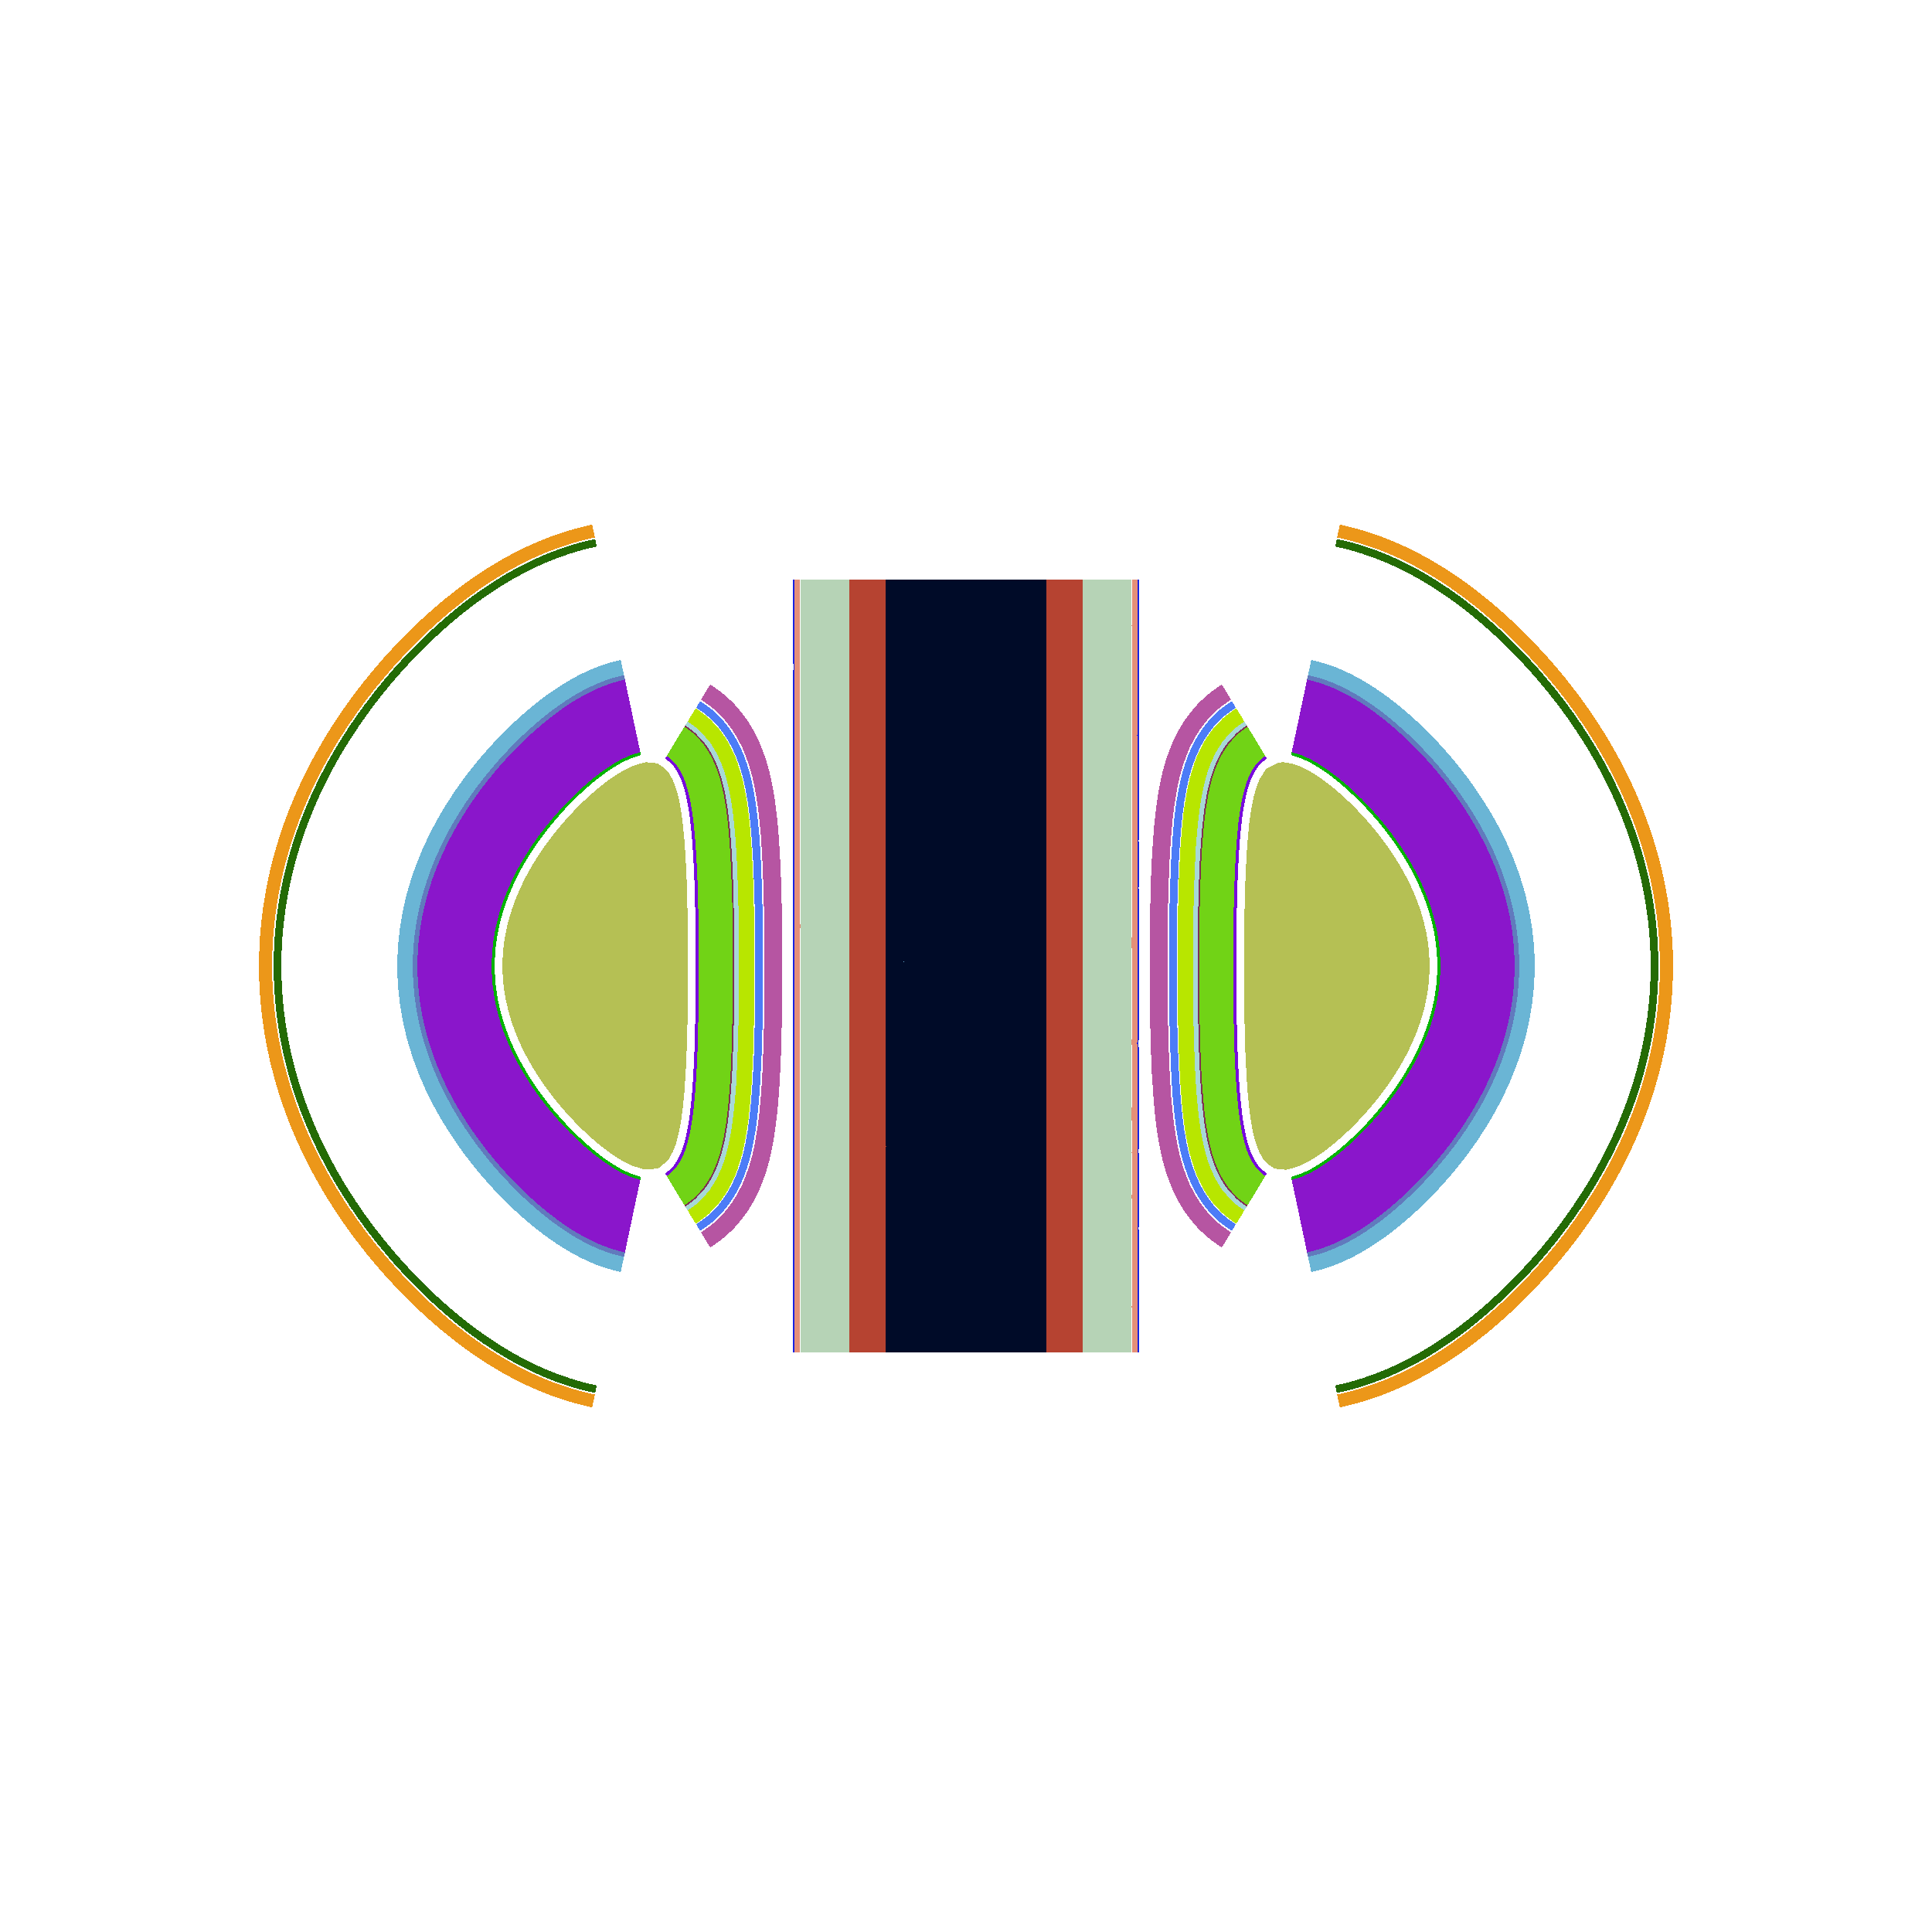

In [10]:
p = openmc.Plot()
p.origin = (0, 10, 0)
p.pixels = (2500, 2500)
p.width = (2500, 2500)
p.basis = 'xz'
p.color_by = 'material'
openmc.plot_inline([p])

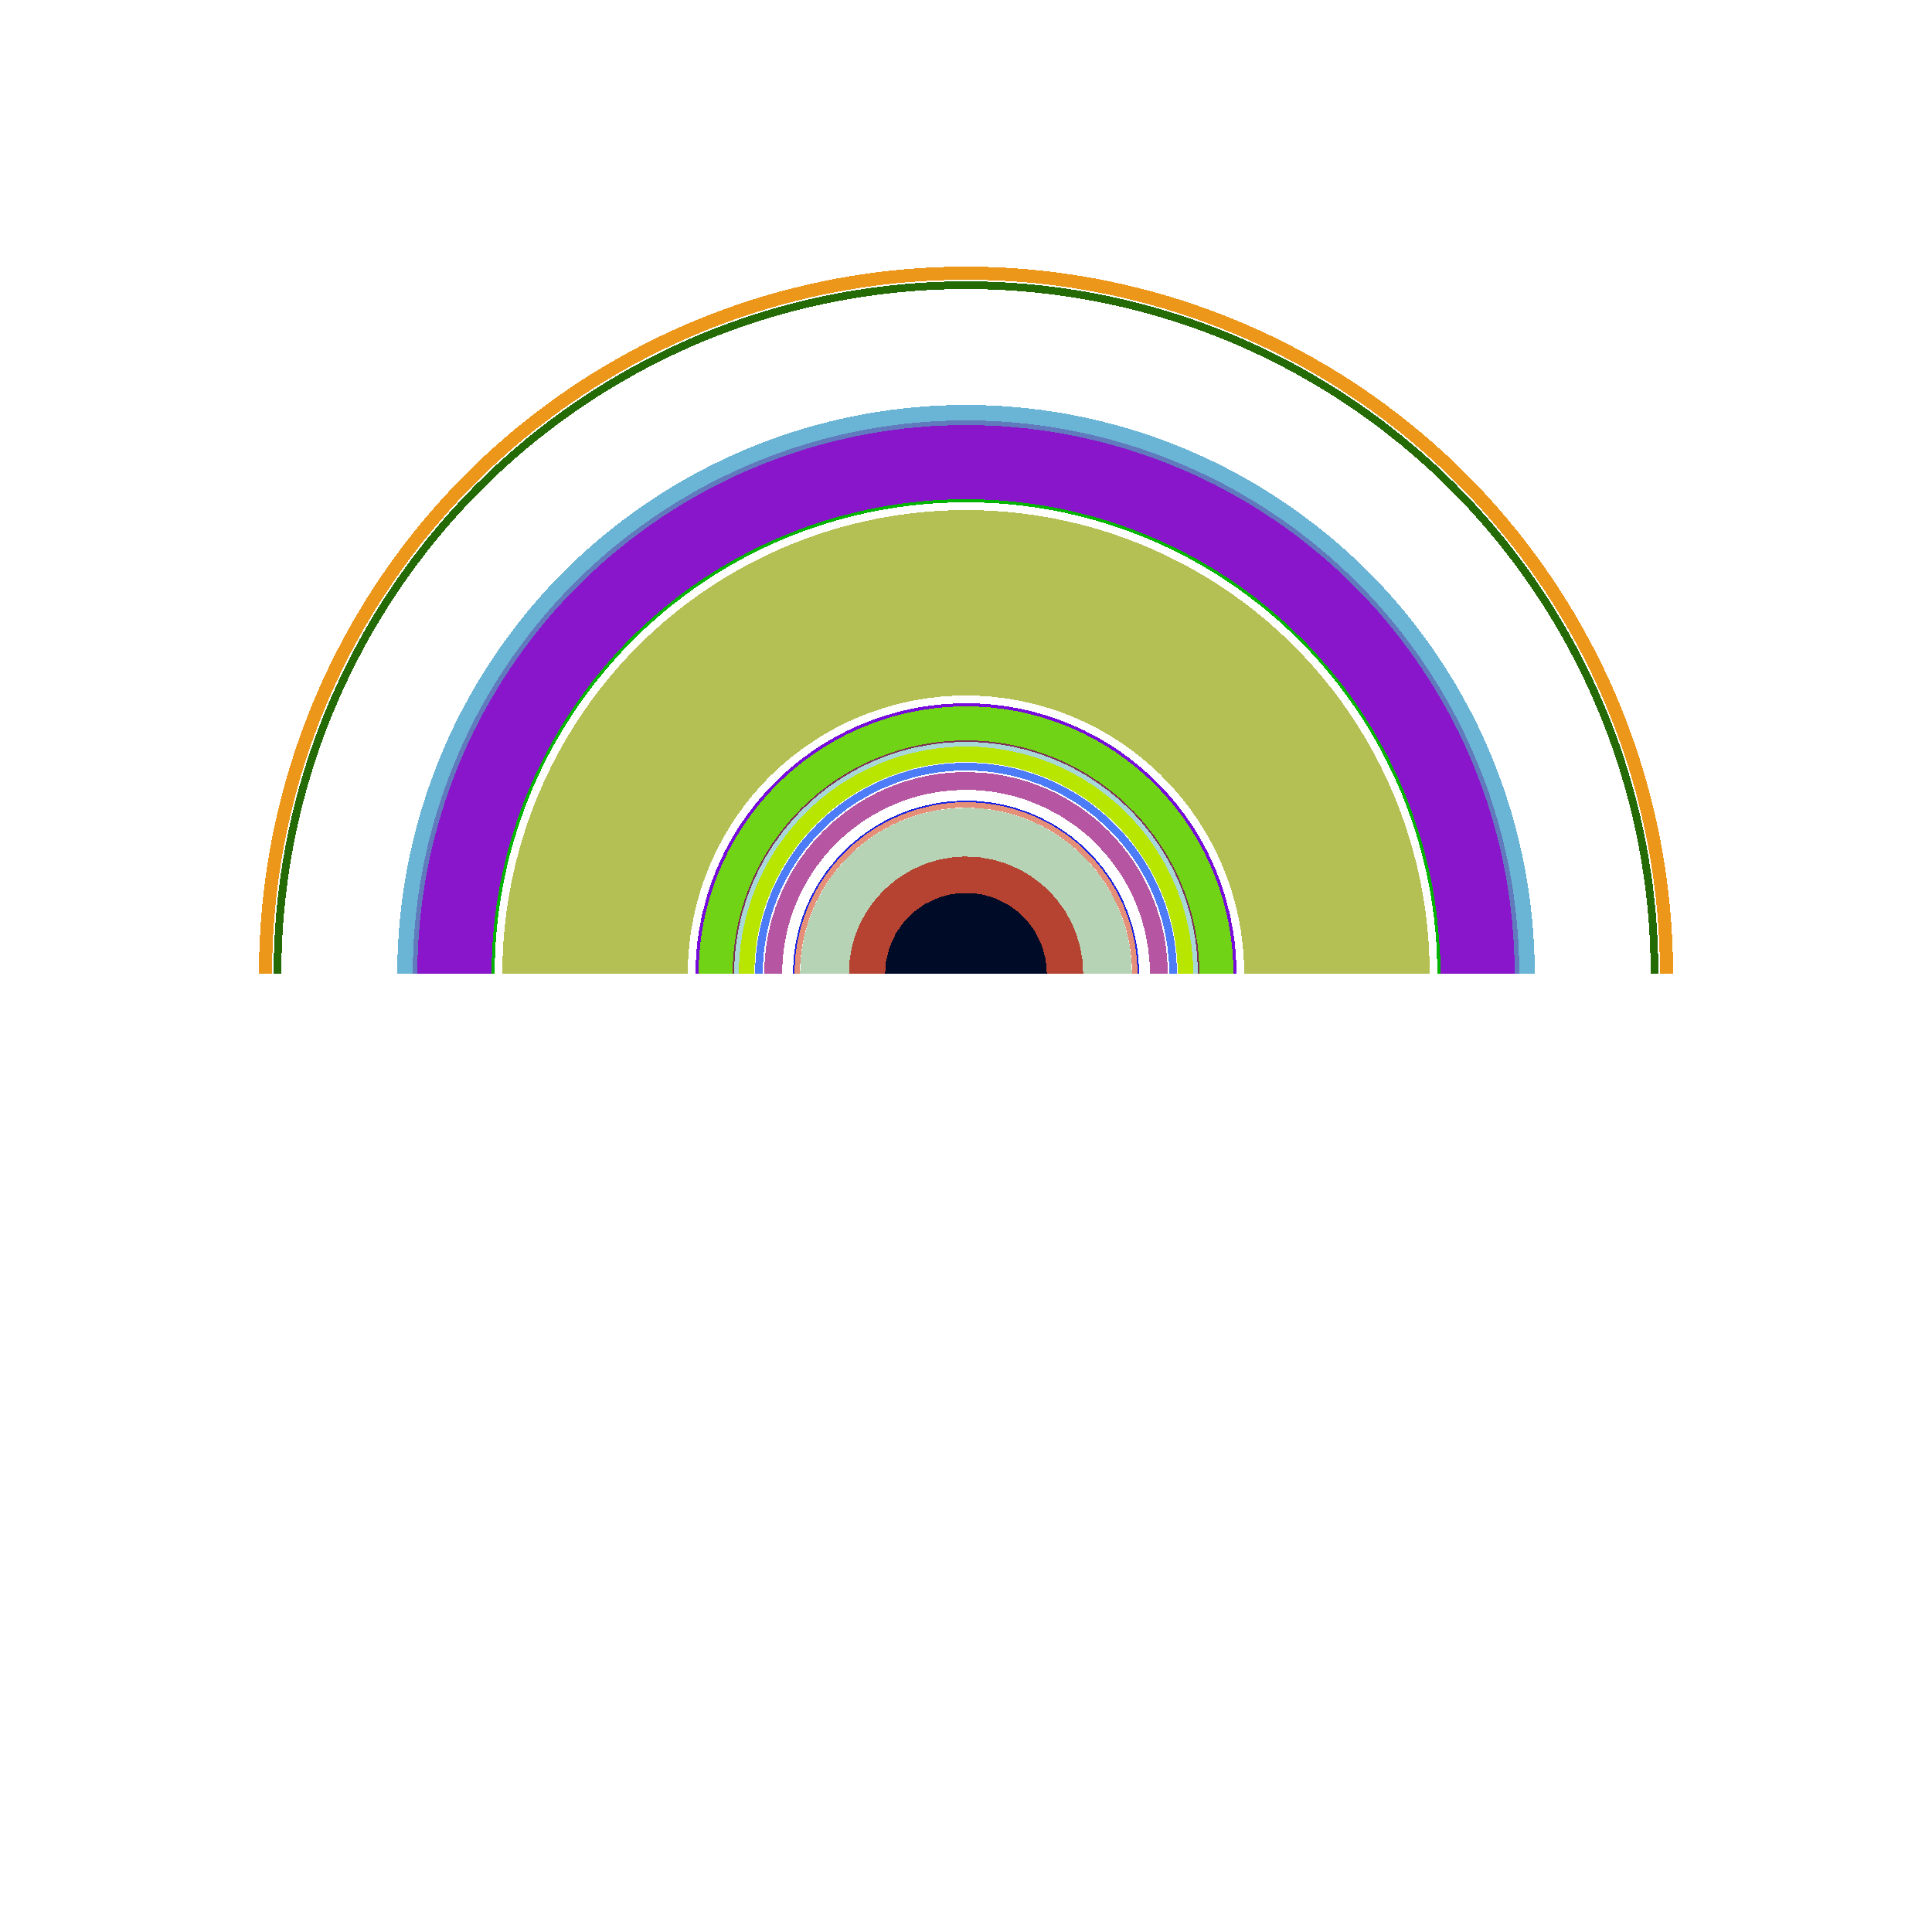

In [11]:
p.basis = 'xy'
openmc.plot_inline(p)

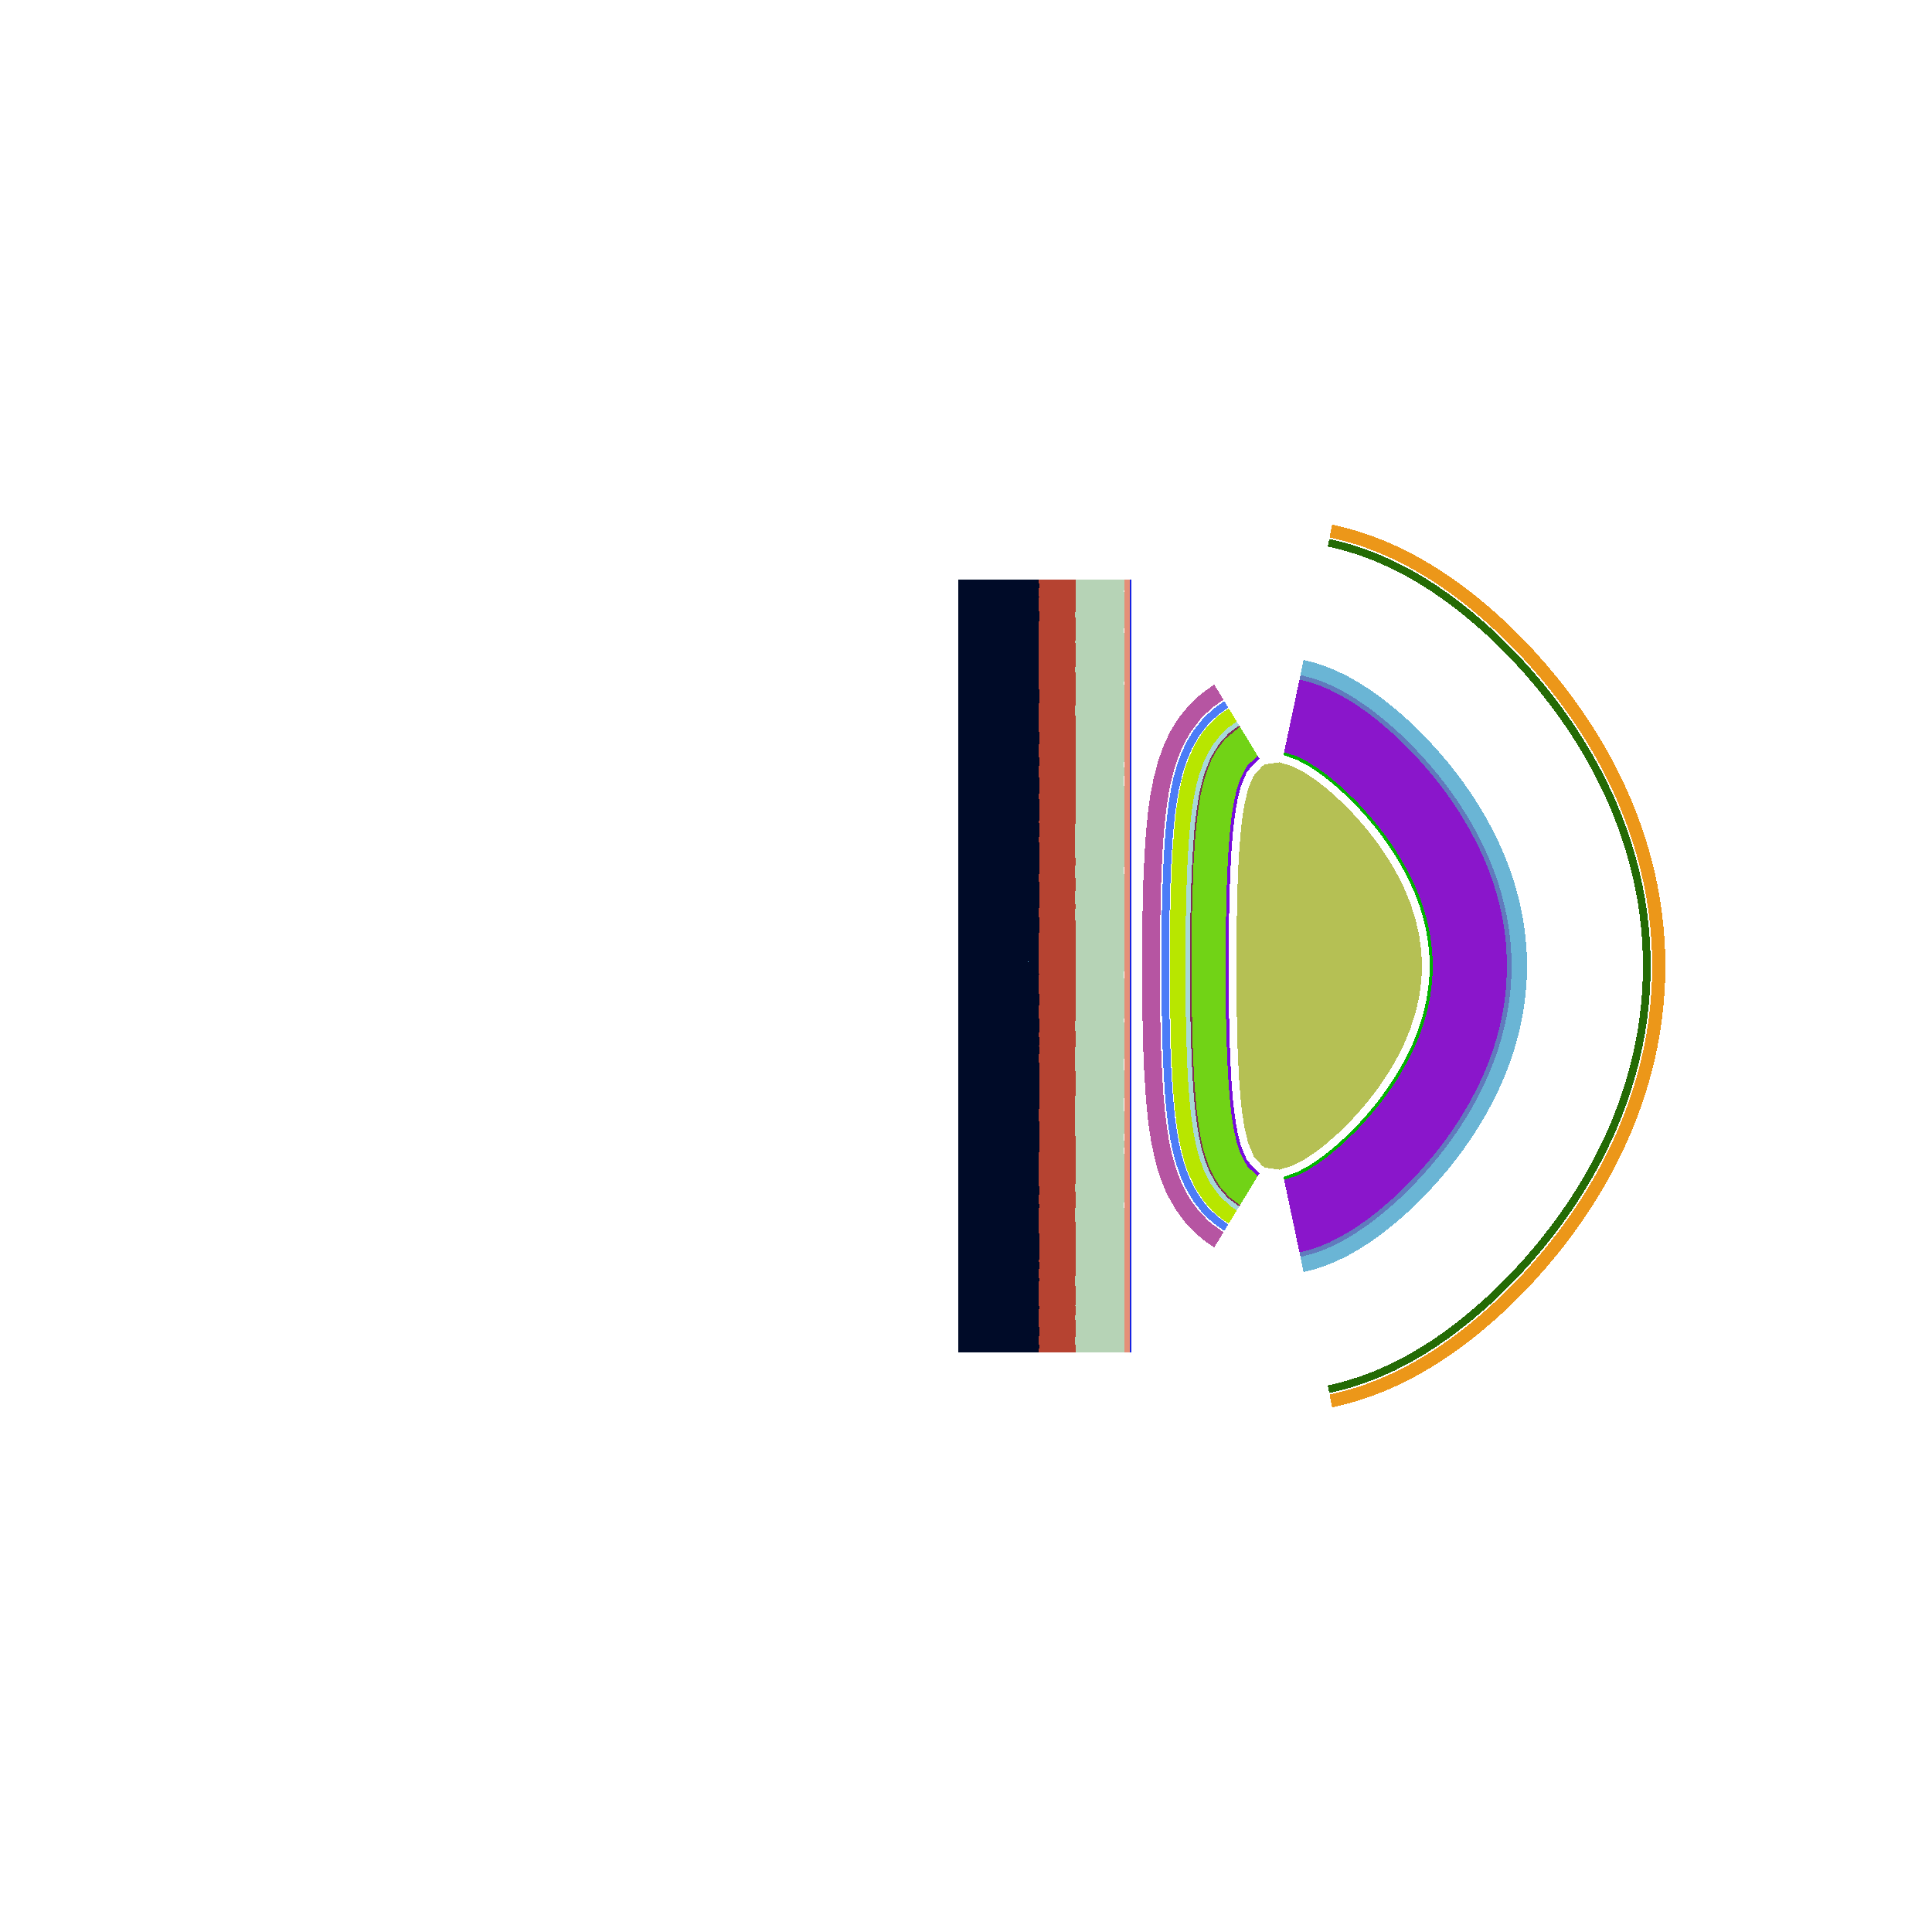

In [12]:
p.basis = 'yz'
openmc.plot_inline(p)

In [25]:
# starts the simulation
!rm -rf *.h5

model.run(threads=16)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

PosixPath('/home/rifat/codes/statepoint.100.h5')

In [26]:
# open the results file
sp = openmc.StatePoint("statepoint.100.h5")

for tally_id, tally in sp.tallies.items():
    print(f"Tally ID: {tally_id}, Tally Name: {tally.name}")


Tally ID: 1, Tally Name: x flux
Tally ID: 2, Tally Name: uheating
Tally ID: 3, Tally Name: heating
Tally ID: 4, Tally Name: tbr
Tally ID: 5, Tally Name: utbr
Tally ID: 6, Tally Name: z flux
Tally ID: 7, Tally Name: energetic flux
Tally ID: 8, Tally Name: absorption
Tally ID: 9, Tally Name: uabsorption
Tally ID: 10, Tally Name: damage energy
Tally ID: 11, Tally Name: udamage energy


In [ ]:
heating_tally=sp.get_tally(name='heating')
heating = heating_tally.get_slice(scores=['heating'])
heating_umesh = heating.find_filter(openmc.MeshFilter).mesh
print(f"The reactor has {heating.mean.sum()/1e6} MeV/source particle deposited")
print(f"Standard deviation on the heating is {heating.std_dev.sum()/1e6}MeV/source particle deposited")

heating_filter = heating.find_filter(openmc.MeshFilter)
heating_mesh = heating_filter.mesh

centroids = heating_mesh.centroids  # not needed in the next release of openmc
mesh_vols = heating_mesh.volumes  # not needed in the next release of openmc

heating_mesh.write_data_to_vtk(
    datasets={"mean": heating.mean.flatten()},
    filename="heating results.vtk",
)
heating_mesh.write_data_to_vtk(
    datasets={"std_dev": heating.std_dev.flatten()},
    filename="heating std dev results.vtk",
)

The reactor has 15.602852503926819 MeV/source particle deposited
Standard deviation on the heating is 1.5156423601354136MeV/source particle deposited


<StructuredGrid(0x638c4b48adc0) at 0x78c3891e4b20>

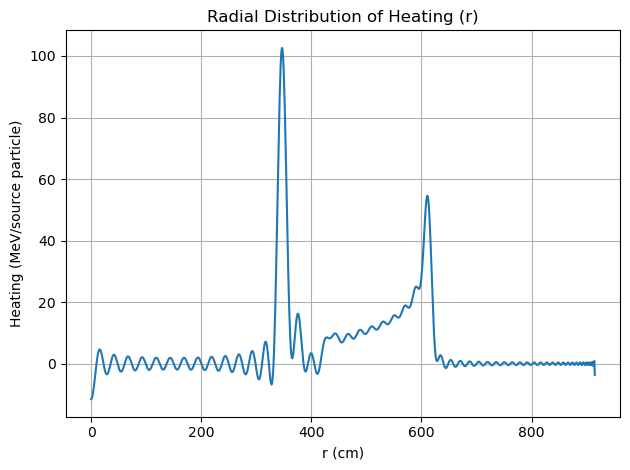

In [27]:
xheating=sp.get_tally(name='uheating')
hdf=xheating.get_pandas_dataframe()
# Spatial domain (along z)
H = openmc.ZernikeRadial(hdf['mean'], radius=915)
r = np.linspace(0, 915, 1000)
# Plot

plt.plot(r, H(r))
plt.yscale('linear')
plt.xlabel('r (cm)')
plt.ylabel('Heating (MeV/source particle)')
plt.title('Radial Distribution of Heating (r)')
plt.grid(True)
plt.tight_layout()
plt.show()

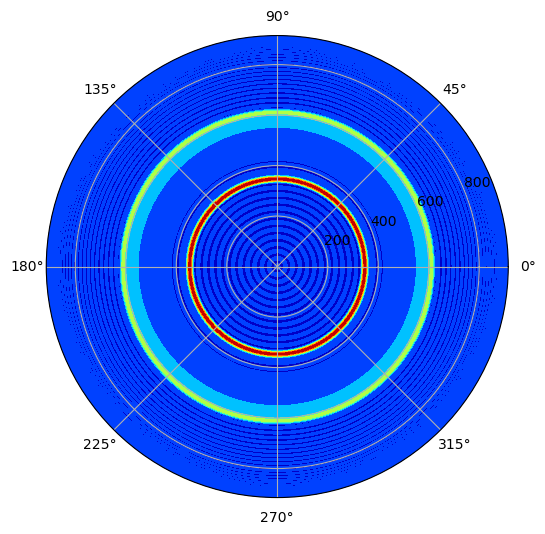

In [ ]:
azimuths = np.radians(np.linspace(0, 360, 1000))
zeniths = np.linspace(0, 915, 1000)
R, theta = np.meshgrid(zeniths, azimuths)
values = [[i for i in H(zeniths)] for j in range(len(azimuths))]
fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(6,6))
ax.contourf(theta, R, values, cmap='jet')
plt.show()

In [ ]:
trit_tally = sp.get_tally(name='tbr')
trit_value = trit_tally.get_values(scores=['(n,Xt)'])
print('trit value:', trit_tally.mean.sum(), "+/-", trit_tally.std_dev.sum())
tdf=trit_tally.get_pandas_dataframe()
print(tdf.head())

trit value: 1.0414526481970805 +/- 0.0004935833775830102
  nuclide   score      mean  std. dev.
0     Li6  (n,Xt)  1.027950   0.000486
1     Li7  (n,Xt)  0.013503   0.000008


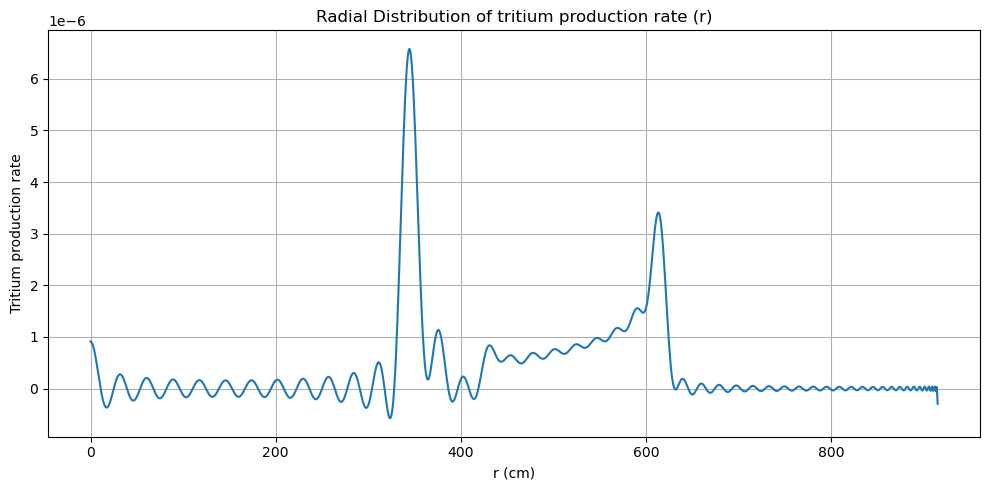

In [ ]:
xtbr=sp.get_tally(name='utbr')
tdf=xtbr.get_pandas_dataframe()
# Spatial domain (along z)
T = openmc.ZernikeRadial(tdf['mean'], radius=915)

r = np.linspace(0, 915, 1000)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(r, T(r))
plt.yscale('linear')
plt.xlabel('r (cm)')
plt.ylabel('Tritium production rate')
plt.title('Radial Distribution of tritium production rate (r)')
plt.grid(True)
plt.tight_layout()
plt.show()

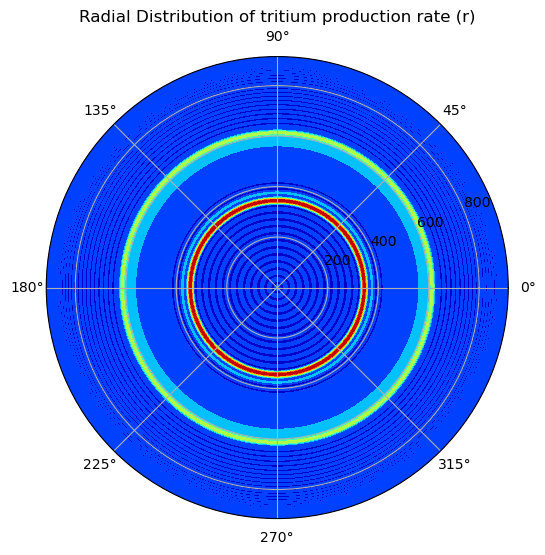

In [ ]:
azimuths = np.radians(np.linspace(0, 360, 1000))
zeniths = np.linspace(0, 915, 1000)
R, theta = np.meshgrid(zeniths, azimuths)
values = [[i for i in T(zeniths)] for j in range(len(azimuths))]
fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(6,6))
ax.contourf(theta, R, values, cmap='jet')
plt.title('Radial Distribution of tritium production rate (r)')
plt.show()

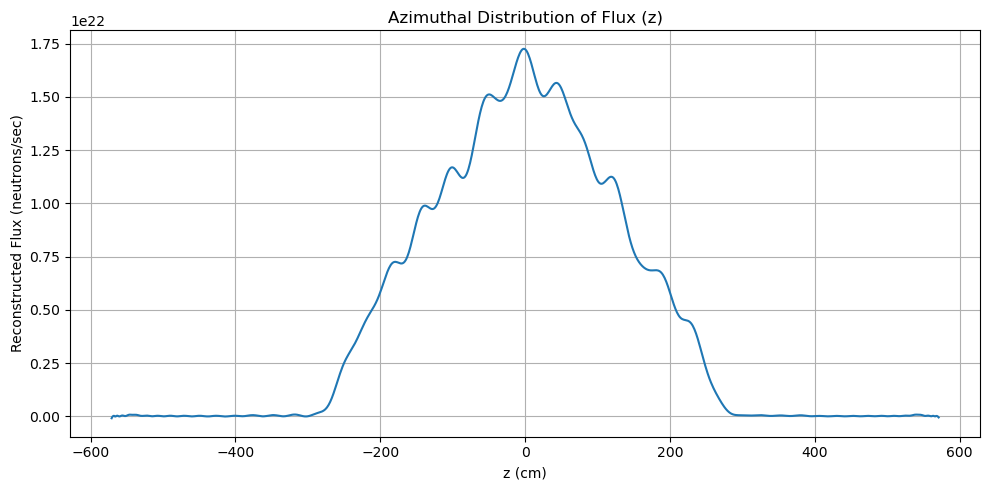

In [29]:
zflux=sp.get_tally(name='z flux')
fdf=zflux.get_pandas_dataframe()
# Spatial domain (along z)
zmin = -571
zmax = 571
order2=100
z_vals = np.linspace(zmin, zmax, 1000)
n = np.arange(order2 + 1)
a_n = (2*n + 1)/2 * fdf['mean']
phi = np.polynomial.Legendre(a_n/10, domain=(zmin, zmax))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(z_vals, phi(z_vals)*1.6e20)
plt.yscale('linear')
plt.xlabel('z (cm)')
plt.ylabel('Reconstructed Flux (neutrons/sec)')
plt.title('Azimuthal Distribution of Flux (z)')
plt.grid(True)
plt.tight_layout()
plt.show()

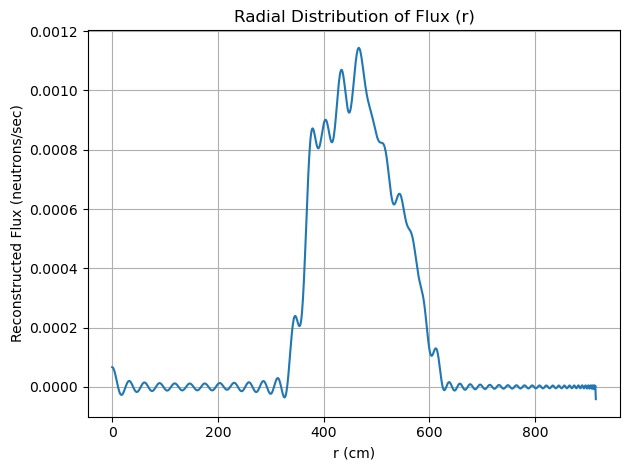

In [31]:
flux=sp.get_tally(name='x flux')
fdf1=flux.get_pandas_dataframe()
# Spatial domain (along z)
F = openmc.ZernikeRadial(fdf1['mean'], radius=915)
r = np.linspace(0, 915, 1000)

# Plot

plt.plot(r, F(r))
plt.yscale('linear')
plt.xlabel('r (cm)')
plt.ylabel('Reconstructed Flux (neutrons/sec)')
plt.title('Radial Distribution of Flux (r)')
plt.grid(True)
plt.tight_layout()
plt.show()

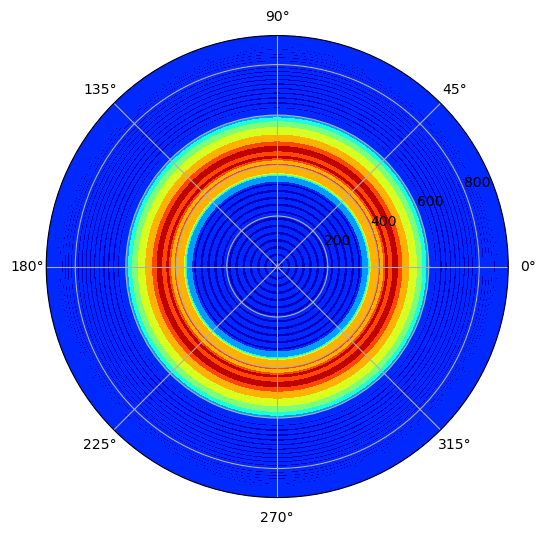

In [ ]:
azimuths = np.radians(np.linspace(0, 360, 1000))
zeniths = np.linspace(0, 915, 1000)
R, theta = np.meshgrid(zeniths, azimuths)
values = [[i for i in F(zeniths)] for j in range(len(azimuths))]
fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(6,6))
ax.contourf(theta, R, values, cmap='jet')
plt.title('Radial Distribution of Flux (r)')
plt.show()

In [33]:
flux1=sp.get_tally(name='energetic flux')
print(flux1.shape)
energy=np.logspace(np.log10(1e-5), np.log10(20.0e6), 1000)
print(energy.shape)
flux2 = flux1.mean.flatten()
print("Energy shape:", np.shape(energy))
print("Flux2 shape:", np.shape(flux2))

(1000, 1, 1)
(1000,)
Energy shape: (1000,)
Flux2 shape: (1000,)


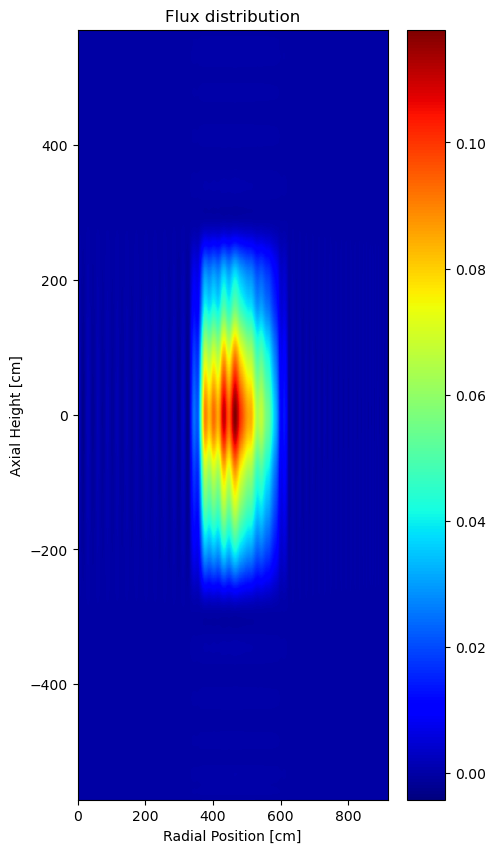

In [34]:
azimuths = np.radians(np.linspace(0, 360, 1000)) # azimuthal mesh 
zeniths = np.linspace(0, 915, 1000) # radial mesh 
zmin, zmax = -571, 571 
z = np.linspace(zmin, zmax, 1000) # axial mesh 
flux = np.array([phi(z)]).T @ np.array([F(zeniths)])

plt.figure(figsize=(5,10))
plt.title('Flux distribution')
plt.xlabel('Radial Position [cm]')
plt.ylabel('Axial Height [cm]')
plt.pcolor(zeniths, z, flux, cmap='jet')
plt.colorbar()

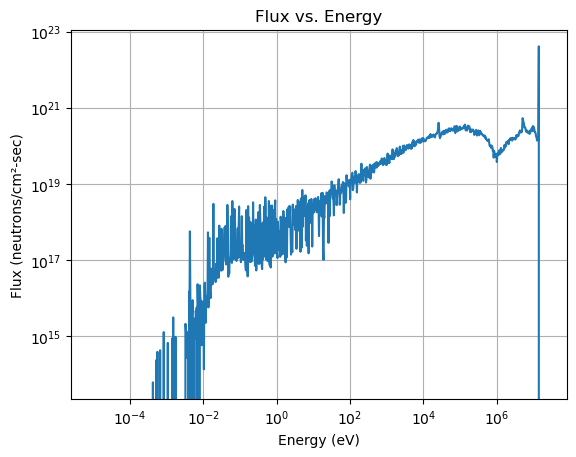

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(energy,flux2*1.6e20, label='Total Neutron Flux')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (eV)')
plt.ylabel('Flux (neutrons/cm²-sec)')
plt.title('Flux vs. Energy')
plt.grid(True)
plt.show()

In [26]:
absorption_tally=sp.get_tally(name='absorption')
absorption = absorption_tally.get_slice(scores=['absorption'])
absorption_umesh = absorption.find_filter(openmc.MeshFilter).mesh
print(f"The reactor has an absorption rate of {absorption.mean.sum()}/source particle deposited")
print(f"Standard deviation on the absorption is {absorption.std_dev.sum()}/source particle deposited")

absorption_filter = absorption.find_filter(openmc.MeshFilter)
absorption_mesh = absorption_filter.mesh

centroids = absorption_mesh.centroids  # not needed in the next release of openmc
mesh_vols = absorption_mesh.volumes  # not needed in the next release of openmc

absorption_mesh.write_data_to_vtk(
    datasets={"mean": absorption.mean.flatten()},
    filename="absorption results.vtk",
)
absorption_mesh.write_data_to_vtk(
    datasets={"std_dev": absorption.std_dev.flatten()},
    filename="absorption std dev results.vtk",
)

The reactor has an absorption rate of 1.0705978773858662/source particle deposited
Standard deviation on the absorption is 0.8326946444885726/source particle deposited


<StructuredGrid(0x5e32bd959af0) at 0x7bbb07828d60>

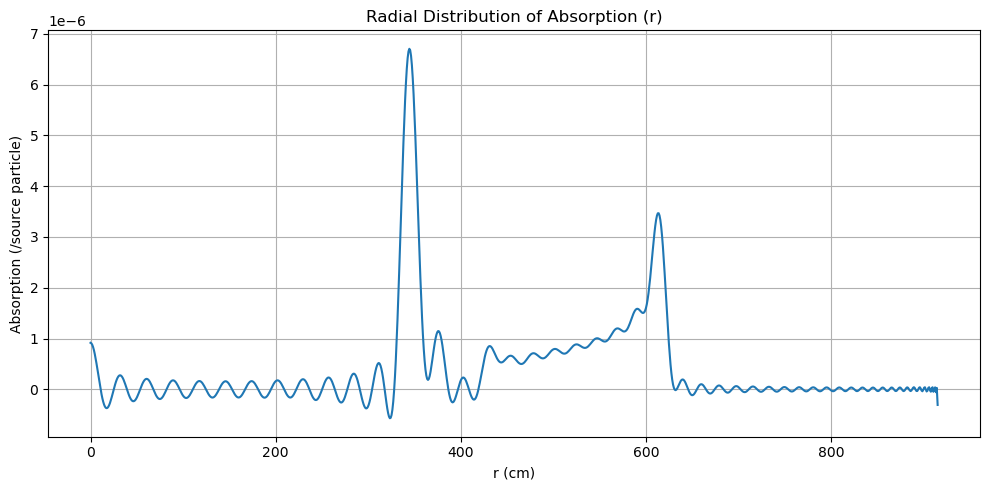

In [35]:
uabsorption_tally=sp.get_tally(name='uabsorption')
uabsorption = uabsorption_tally.get_slice(scores=['absorption'])
udf=uabsorption.get_pandas_dataframe()

# Spatial domain (along z)
A = openmc.ZernikeRadial(udf['mean'], radius=915)
r = np.linspace(0, 915, 1000)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(r, A(r))
plt.xlabel('r (cm)')
plt.ylabel('Absorption (/source particle)')
plt.title('Radial Distribution of Absorption (r)')
plt.grid(True)
plt.tight_layout()
plt.show()

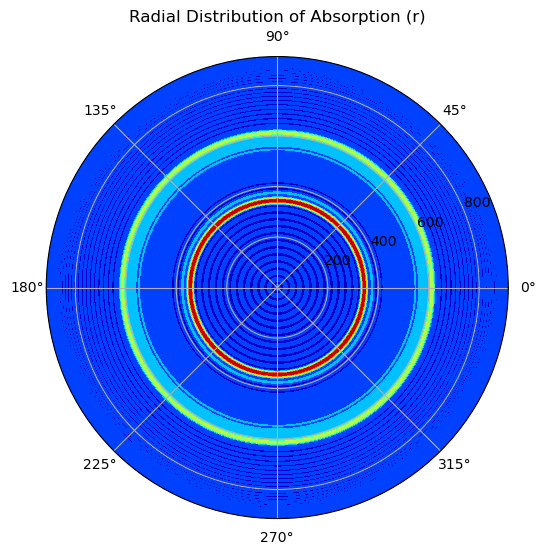

In [39]:
azimuths = np.radians(np.linspace(0, 360, 1000))
zeniths = np.linspace(0, 915, 1000)
R, theta = np.meshgrid(zeniths, azimuths)
values = [[i for i in A(zeniths)] for j in range(len(azimuths))]
fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(6,6))
ax.contourf(theta, R, values, cmap='jet')
plt.title('Radial Distribution of Absorption (r)')
plt.show()

In [ ]:
edmg_tally=sp.get_tally(name='damage energy')
edmg = edmg_tally.get_slice(scores=['damage-energy'])
edmg_umesh = edmg.find_filter(openmc.MeshFilter).mesh
print(f"The reactor has an damage energy of {edmg.mean.sum()/1e6} MeV/source particle deposited")
print(f"Standard deviation on the absorption is {edmg.std_dev.sum()/1e6} MeV/source particle deposited")

edmg_filter = edmg.find_filter(openmc.MeshFilter)
edmg_mesh = edmg_filter.mesh

centroids = edmg_umesh.centroids  # not needed in the next release of openmc
mesh_vols = edmg_umesh.volumes  # not needed in the next release of openmc

edmg_mesh.write_data_to_vtk(
    datasets={"mean": edmg.mean.flatten()},
    filename="edmg results.vtk",
)
edmg_mesh.write_data_to_vtk(
    datasets={"std_dev": edmg.std_dev.flatten()},
    filename="edmg std dev results.vtk",
)

The reactor has an damage energy of 0.10630733702285314 MeV/source particle deposited
Standard deviation on the absorption is 0.07107927298299828 MeV/source particle deposited


<StructuredGrid(0x60a7aa70c690) at 0x782fc2688ac0>

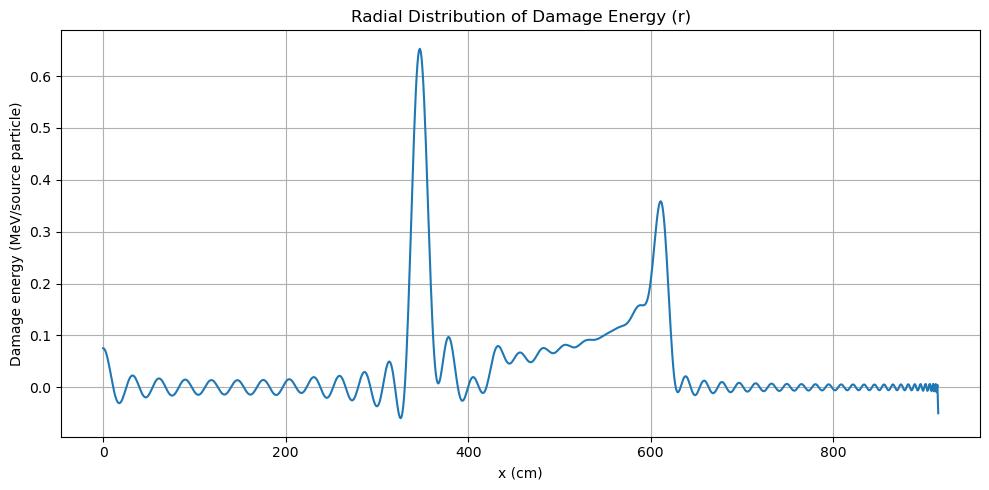

In [38]:
uedmg_tally=sp.get_tally(name='udamage energy')
uedmg = uedmg_tally.get_slice(scores=['damage-energy'])

edf=uedmg.get_pandas_dataframe()

E = openmc.ZernikeRadial(edf['mean'], radius=915)
r = np.linspace(0, 915, 1000)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(r, E(r))
plt.xlabel('x (cm)')
plt.ylabel('Damage energy (MeV/source particle)')
plt.title('Radial Distribution of Damage Energy (r)')
plt.grid(True)
plt.tight_layout()
plt.show()

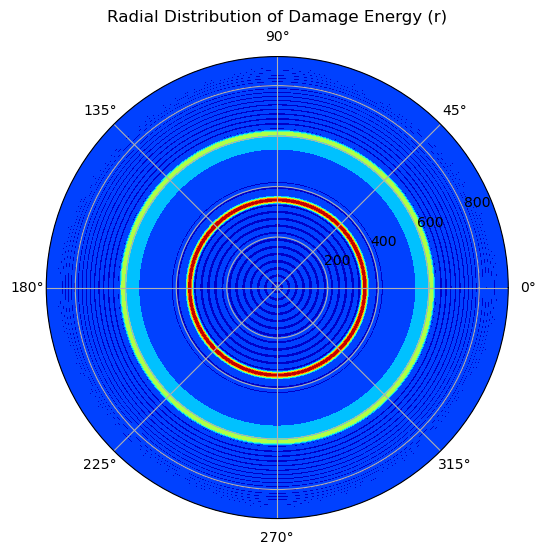

In [41]:
azimuths = np.radians(np.linspace(0, 360, 1000))
zeniths = np.linspace(0, 915, 1000)
R, theta = np.meshgrid(zeniths, azimuths)
values = [[i for i in E(zeniths)] for j in range(len(azimuths))]
fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(6,6))
ax.contourf(theta, R, values, cmap='jet')
plt.title('Radial Distribution of Damage Energy (r)')
plt.show()